# 03 — Compartment-based temporal transitions

Use the existing `compartment_mana` annotations (biologically named spatial
compartments including lesion subtypes) to build sample-level feature vectors
that track how spatial organization changes across disease stages.

Key idea: the signal isn't "which individual niche changes" but rather
"how do the proportions, compositions, and relationships between spatial
compartments shift at each disease stage?"

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../src")

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from temporal_foundation.config import (
    MODELS, SHARED_STAGES, STAGE_KEY, MODEL_KEY, REGION_KEY, SAMPLE_KEY,
    get_all_stages, get_transition_pairs, model_short_name,
)

COMPARTMENT_KEY = "compartment_mana"

In [ ]:
from temporal_foundation.data import load_adata

adata = load_adata()

# Check compartment annotations
compartments = sorted(adata.obs[COMPARTMENT_KEY].dropna().unique())
print(f"Compartments ({len(compartments)}):")
for c in compartments:
    n = (adata.obs[COMPARTMENT_KEY] == c).sum()
    print(f"  {c:40s} {n:>8,} cells")

Loading /Volumes/processing2/RRmap/data/rrmap.companion.ready.h5ad...

## 1. Build sample-level feature vectors

For each sample, compute:
- **Compartment proportions**: what fraction of cells belongs to each compartment
- **Cell type composition per compartment**: L2 cell type proportions within each compartment
- **Lesion burden**: total fraction of cells in any lesion compartment

In [ ]:
CELL_TYPE_KEY = "anno_L2"
cell_types = sorted(adata.obs[CELL_TYPE_KEY].dropna().unique())

sample_ids = adata.obs[SAMPLE_KEY].unique()
print(f"Building features for {len(sample_ids)} samples...")

records = []
for sid in sample_ids:
    mask = adata.obs[SAMPLE_KEY] == sid
    sub = adata.obs.loc[mask]
    n_cells = mask.sum()
    
    record = {
        "sample_id": sid,
        "model": model_short_name(sub[MODEL_KEY].iloc[0]),
        "stage": sub[STAGE_KEY].iloc[0],
        "region": sub[REGION_KEY].iloc[0],
        "n_cells": n_cells,
    }
    
    # Clinical score if available
    if "score_sacrifice" in sub.columns:
        record["clinical_score"] = sub["score_sacrifice"].iloc[0]
    
    # Compartment proportions
    comp_counts = sub[COMPARTMENT_KEY].value_counts()
    for c in compartments:
        record[f"prop_{c}"] = comp_counts.get(c, 0) / n_cells
    
    # Lesion burden (sum of all lesion compartments)
    lesion_comps = [c for c in compartments if "lesion" in c.lower()]
    record["lesion_burden"] = sum(record[f"prop_{c}"] for c in lesion_comps)
    
    # Cell type composition per compartment
    for comp in compartments:
        comp_mask = sub[COMPARTMENT_KEY] == comp
        n_comp = comp_mask.sum()
        if n_comp > 0:
            ct_counts = sub.loc[comp_mask, CELL_TYPE_KEY].value_counts()
            for ct in cell_types:
                record[f"ct_{comp}_{ct}"] = ct_counts.get(ct, 0) / n_comp
        else:
            for ct in cell_types:
                record[f"ct_{comp}_{ct}"] = 0.0
    
    records.append(record)

sample_df = pd.DataFrame(records)
print(f"Feature matrix: {sample_df.shape[0]} samples x {sample_df.shape[1]} features")

# Separate metadata from features
meta_cols = ["sample_id", "model", "stage", "region", "n_cells", "clinical_score"]
meta_cols = [c for c in meta_cols if c in sample_df.columns]
feature_cols = [c for c in sample_df.columns if c not in meta_cols]
print(f"Metadata columns: {len(meta_cols)}")
print(f"Feature columns: {len(feature_cols)}")
print(f"  - Compartment proportions: {len([c for c in feature_cols if c.startswith('prop_')])}")
print(f"  - Lesion burden: 1")
print(f"  - Cell type per compartment: {len([c for c in feature_cols if c.startswith('ct_')])}")

Building features for 107 samples...
Feature matrix: 107 samples x 337 features
Metadata columns: 6
Feature columns: 331
  - Compartment proportions: 15
  - Lesion burden: 1
  - Cell type per compartment: 315


## 2. Compartment proportions across disease stages

How does the spatial makeup of tissue change across the disease trajectory?

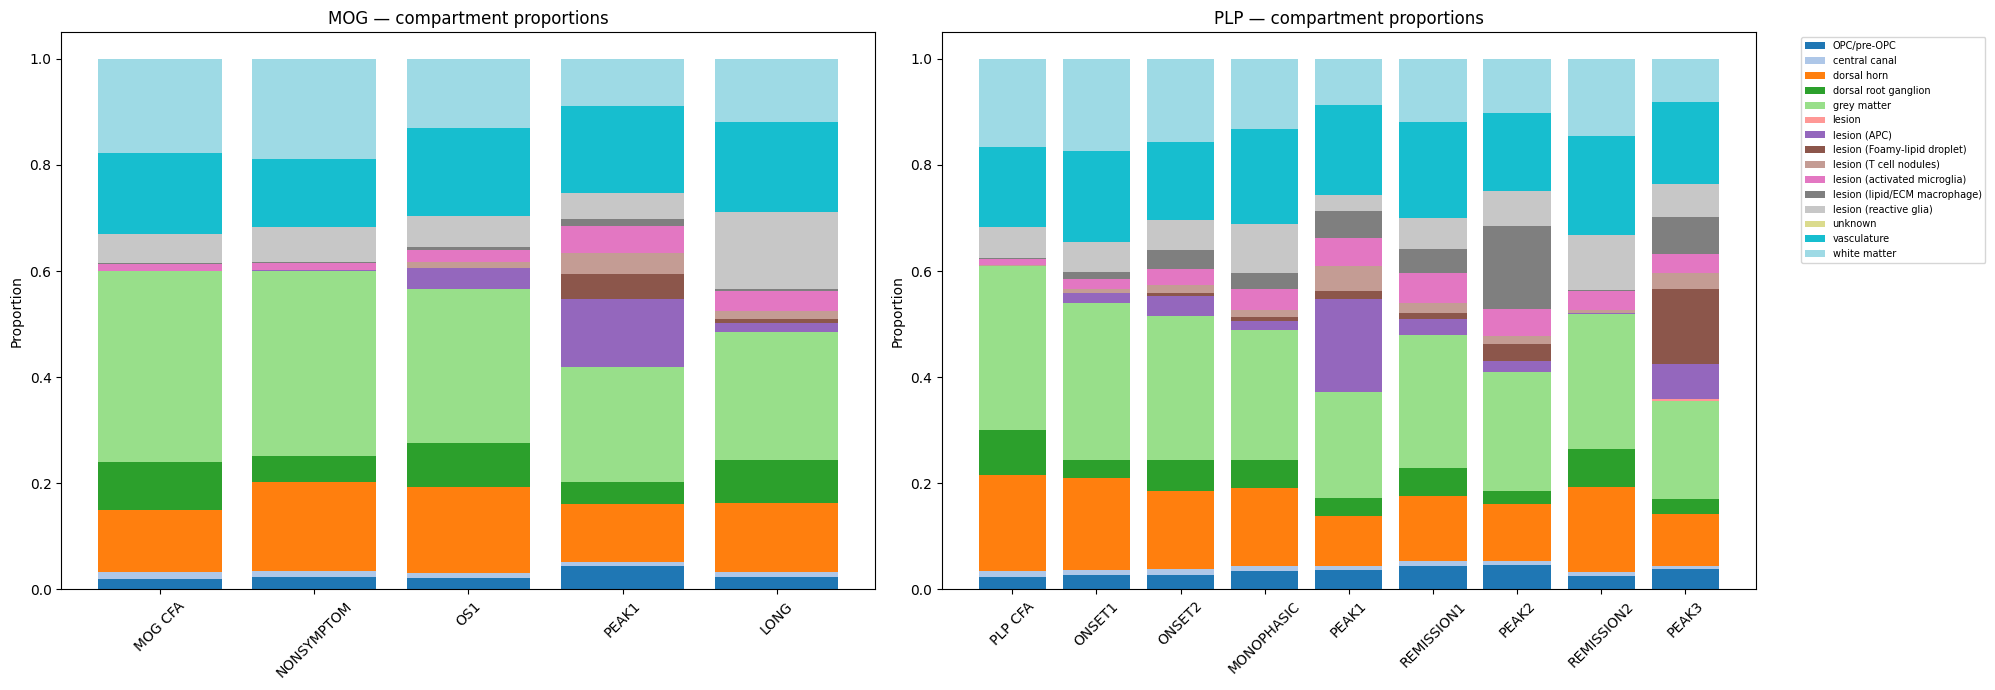

In [ ]:
# Compartment proportions across PLP trajectory
prop_cols = [c for c in feature_cols if c.startswith("prop_")]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, model_name in zip(axes, ["MOG", "PLP"]):
    stages = get_all_stages()[model_name]
    model_df = sample_df[sample_df["model"] == model_name]
    
    # Mean proportions per stage
    stage_props = []
    stage_labels = []
    for stage in stages:
        stage_df = model_df[model_df["stage"] == stage]
        if len(stage_df) == 0:
            continue
        stage_props.append(stage_df[prop_cols].mean().values)
        stage_labels.append(stage)
    
    stage_props = np.array(stage_props)
    comp_names = [c.replace("prop_", "") for c in prop_cols]
    
    # Stacked bar chart
    bottom = np.zeros(len(stage_labels))
    colors = plt.cm.tab20(np.linspace(0, 1, len(comp_names)))
    
    for i, comp in enumerate(comp_names):
        ax.bar(stage_labels, stage_props[:, i], bottom=bottom, label=comp, color=colors[i])
        bottom += stage_props[:, i]
    
    ax.set_ylabel("Proportion")
    ax.set_title(f"{model_name} — compartment proportions")
    ax.tick_params(axis="x", rotation=45)

axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

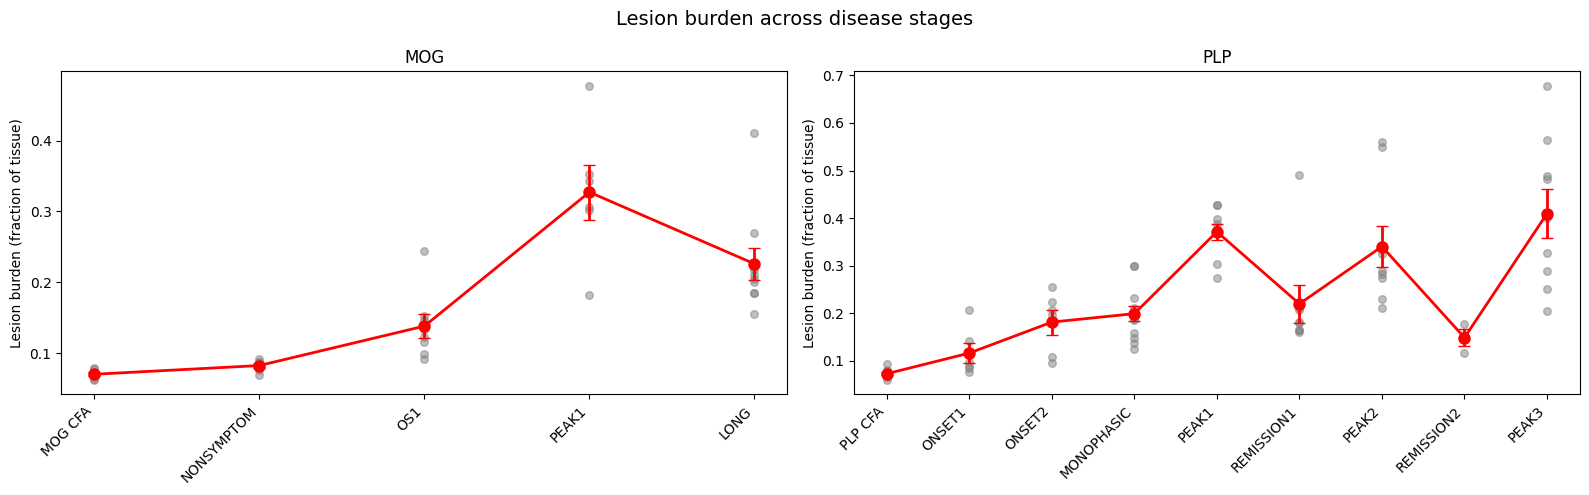

In [ ]:
# Lesion burden trajectory — this is the key temporal signal
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model_name in zip(axes, ["MOG", "PLP"]):
    stages = get_all_stages()[model_name]
    model_df = sample_df[sample_df["model"] == model_name]
    
    # Individual samples as dots
    for i, stage in enumerate(stages):
        stage_df = model_df[model_df["stage"] == stage]
        ax.scatter([i] * len(stage_df), stage_df["lesion_burden"], 
                   c="grey", alpha=0.5, s=30, zorder=2)
    
    # Mean trajectory as line
    means = [model_df[model_df["stage"] == s]["lesion_burden"].mean() for s in stages]
    sems = [model_df[model_df["stage"] == s]["lesion_burden"].sem() for s in stages]
    ax.errorbar(range(len(stages)), means, yerr=sems, 
                color="red", linewidth=2, marker="o", markersize=8, zorder=3, capsize=4)
    
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, rotation=45, ha="right")
    ax.set_ylabel("Lesion burden (fraction of tissue)")
    ax.set_title(f"{model_name}")

plt.suptitle("Lesion burden across disease stages", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Lesion subtype dynamics

Track each lesion compartment separately across the PLP trajectory.
Which lesion subtypes expand at peak and resolve at remission?

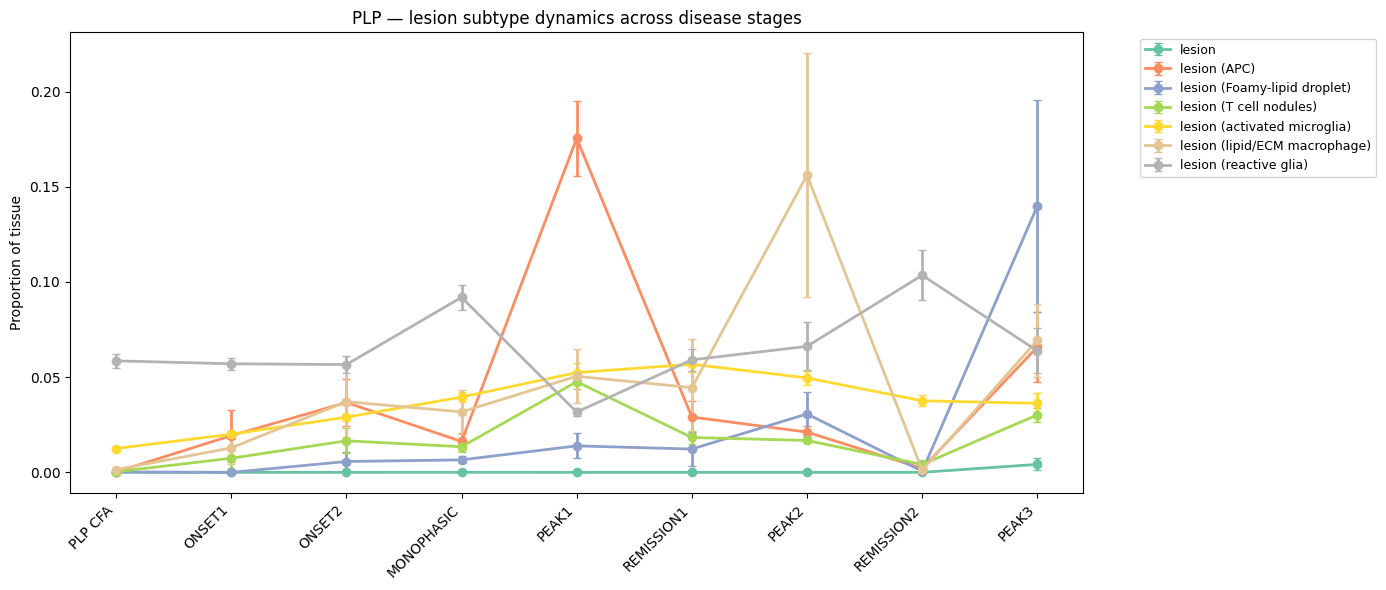

In [ ]:
# Lesion subtype trajectories for PLP
lesion_cols = [c for c in prop_cols if "lesion" in c.lower()]
lesion_names = [c.replace("prop_", "") for c in lesion_cols]

plp_stages = get_all_stages()["PLP"]
plp_df = sample_df[sample_df["model"] == "PLP"]

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.Set2(np.linspace(0, 1, max(len(lesion_names), 1)))
x_labels = [s for s in plp_stages if (plp_df["stage"] == s).any()]

for i, (col, name) in enumerate(zip(lesion_cols, lesion_names)):
    means = []
    sems = []
    for stage in x_labels:
        stage_df = plp_df[plp_df["stage"] == stage]
        means.append(stage_df[col].mean())
        sems.append(stage_df[col].sem())
    
    ax.errorbar(range(len(x_labels)), means, yerr=sems,
                label=name, color=colors[i], linewidth=2, marker="o", capsize=3)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("Proportion of tissue")
ax.set_title("PLP — lesion subtype dynamics across disease stages")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Sample-level PCA on compartment features

Project samples into a low-dimensional space using all compartment features.
Are disease stages separable? Does region drive more variance than disease?

Variance explained: PC1=12.0%, PC2=5.6%, PC3=3.8%
Cumulative (5 PCs): 27.7%


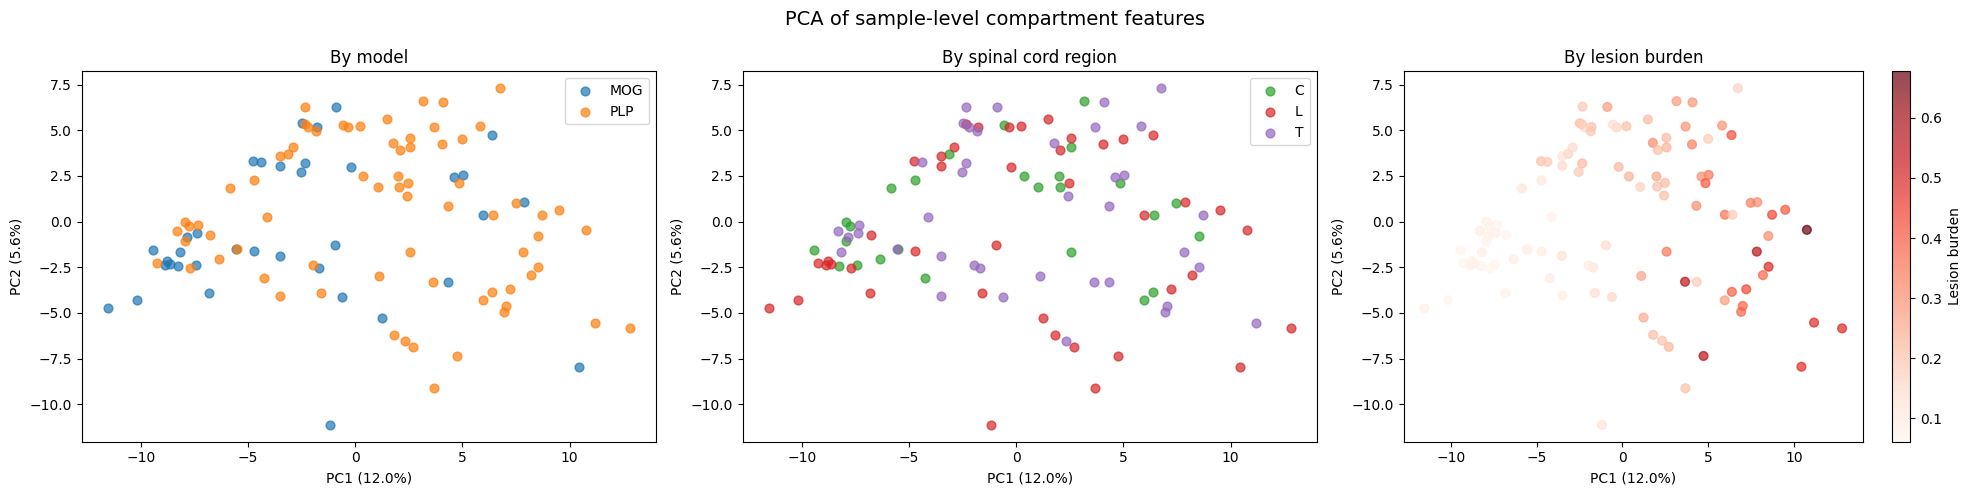

In [ ]:
# PCA on all features
X = sample_df[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=min(20, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"PC3={pca.explained_variance_ratio_[2]:.1%}")
print(f"Cumulative (5 PCs): {pca.explained_variance_ratio_[:5].sum():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Color by model
model_colors = {"MOG": "tab:blue", "PLP": "tab:orange"}
for model_name, color in model_colors.items():
    mask = sample_df["model"] == model_name
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=model_name, s=40, alpha=0.7)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].legend()
axes[0].set_title("By model")

# Color by region
region_colors = {"C": "tab:green", "L": "tab:red", "T": "tab:purple"}
for region, color in region_colors.items():
    mask = sample_df["region"] == region
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=region, s=40, alpha=0.7)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].legend()
axes[1].set_title("By spinal cord region")

# Color by lesion burden
scatter = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=sample_df["lesion_burden"], 
                          cmap="Reds", s=40, alpha=0.7)
plt.colorbar(scatter, ax=axes[2], label="Lesion burden")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[2].set_title("By lesion burden")

plt.suptitle("PCA of sample-level compartment features", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Transition analysis on compartment features

Compute transition vectors and similarities using the compartment-based
features instead of Novae embeddings. These features are directly interpretable.

In [ ]:
# Compute mean feature vector per (model, stage)
stage_means = {}
for model_name in ["MOG", "PLP"]:
    for stage in get_all_stages()[model_name]:
        mask = (sample_df["model"] == model_name) & (sample_df["stage"] == stage)
        if mask.sum() > 0:
            stage_means[(model_name, stage)] = sample_df.loc[mask, feature_cols].mean().values

# Transition vectors and what changes most at each transition
print("=== PLP: What changes most at each transition? ===\n")
plp_pairs = get_transition_pairs("PLP")
for from_s, to_s in plp_pairs:
    k1, k2 = ("PLP", from_s), ("PLP", to_s)
    if k1 not in stage_means or k2 not in stage_means:
        continue
    
    delta = stage_means[k2] - stage_means[k1]
    
    # Focus on compartment proportions
    prop_idx = [i for i, c in enumerate(feature_cols) if c.startswith("prop_")]
    prop_delta = [(feature_cols[i].replace("prop_", ""), delta[i]) for i in prop_idx]
    prop_delta.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print(f"{from_s} -> {to_s}:")
    for name, d in prop_delta[:5]:
        if abs(d) > 0.001:
            direction = "+" if d > 0 else "-"
            bar = "|" * int(abs(d) * 200)
            print(f"  {name:40s} {d:+.4f} {bar}")
    print()

=== PLP: What changes most at each transition? ===

PLP CFA -> ONSET1:
  dorsal root ganglion                     -0.0502 ||||||||||
  vasculature                              +0.0211 ||||
  lesion (APC)                             +0.0191 |||
  grey matter                              -0.0152 |||
  lesion (lipid/ECM macrophage)            +0.0114 ||

ONSET1 -> ONSET2:
  vasculature                              -0.0256 |||||
  dorsal horn                              -0.0247 ||||
  lesion (lipid/ECM macrophage)            +0.0243 ||||
  grey matter                              -0.0230 ||||
  dorsal root ganglion                     +0.0229 ||||

ONSET2 -> MONOPHASIC:
  lesion (reactive glia)                   +0.0353 |||||||
  vasculature                              +0.0336 ||||||
  white matter                             -0.0257 |||||
  grey matter                              -0.0256 |||||
  lesion (APC)                             -0.0205 ||||

MONOPHASIC -> PEAK1:
  lesion (APC) 

## 6. MOG vs PLP at PEAK1 — compartment-level differences

What's different about the spatial organization of tissue that will remit
vs. tissue that goes chronic?

In [ ]:
# Cross-model comparison at PEAK1
mog_peak = sample_df[(sample_df["model"] == "MOG") & (sample_df["stage"] == "PEAK1")]
plp_peak = sample_df[(sample_df["model"] == "PLP") & (sample_df["stage"] == "PEAK1")]

print(f"MOG PEAK1: {len(mog_peak)} samples")
print(f"PLP PEAK1: {len(plp_peak)} samples\n")

# Compartment proportion differences
print("Compartment proportion differences (PLP minus MOG):")
print("  Positive = more in PLP (will remit)")
print("  Negative = more in MOG (goes chronic)\n")

diffs = []
for col in prop_cols:
    name = col.replace("prop_", "")
    mog_mean = mog_peak[col].mean()
    plp_mean = plp_peak[col].mean()
    delta = plp_mean - mog_mean
    diffs.append((name, delta, mog_mean, plp_mean))

diffs.sort(key=lambda x: abs(x[1]), reverse=True)
for name, delta, mog_m, plp_m in diffs:
    if abs(delta) > 0.005:
        bar = "+" * int(abs(delta) * 100) if delta > 0 else "-" * int(abs(delta) * 100)
        print(f"  {name:40s} MOG={mog_m:.3f}  PLP={plp_m:.3f}  delta={delta:+.4f}  {bar}")

NameError: name 'sample_df' is not defined

## 7. Feature importance for predicting disease direction

Which compartment features best predict whether a sample transitions
toward recovery vs. continued disease? Use a simple classifier on the
compartment features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict

# Build classification task: can we predict the next disease direction from current features?
# Label each sample by what happens next: "recovery" or "disease" or "chronic"
train_records = []
for model_name in ["MOG", "PLP"]:
    pairs = get_transition_pairs(model_name)
    for from_stage, to_stage in pairs:
        # Determine direction
        if "REMISSION" in to_stage:
            direction = "recovery"
        elif "LONG" in to_stage:
            direction = "chronic"
        else:
            direction = "disease"
        
        mask = (sample_df["model"] == model_name) & (sample_df["stage"] == from_stage)
        for idx in sample_df[mask].index:
            train_records.append({
                "idx": idx,
                "model": model_name,
                "from_stage": from_stage,
                "to_stage": to_stage,
                "direction": direction,
            })

train_meta = pd.DataFrame(train_records)
print(f"Classification samples: {len(train_meta)}")
print(f"\nDirection distribution:")
print(train_meta["direction"].value_counts())

X_cls = sample_df.loc[train_meta["idx"], feature_cols].fillna(0).values
y_cls = train_meta["direction"].values

# Random Forest with LOO
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
y_pred = cross_val_predict(rf, X_cls, y_cls, cv=LeaveOneOut())
accuracy = (y_pred == y_cls).mean()
print(f"\nLOO accuracy: {accuracy:.1%}")

# Confusion
from sklearn.metrics import classification_report
print(f"\n{classification_report(y_cls, y_pred)}")

Classification samples: 88

Direction distribution:
direction
disease     64
recovery    18
chronic      6
Name: count, dtype: int64

LOO accuracy: 83.0%

              precision    recall  f1-score   support

     chronic       0.00      0.00      0.00         6
     disease       0.87      0.97      0.92        64
    recovery       0.65      0.61      0.63        18

    accuracy                           0.83        88
   macro avg       0.51      0.53      0.52        88
weighted avg       0.77      0.83      0.80        88



/Users/christoffer/miniconda3/envs/novae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/christoffer/miniconda3/envs/novae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/christoffer/miniconda3/envs/novae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

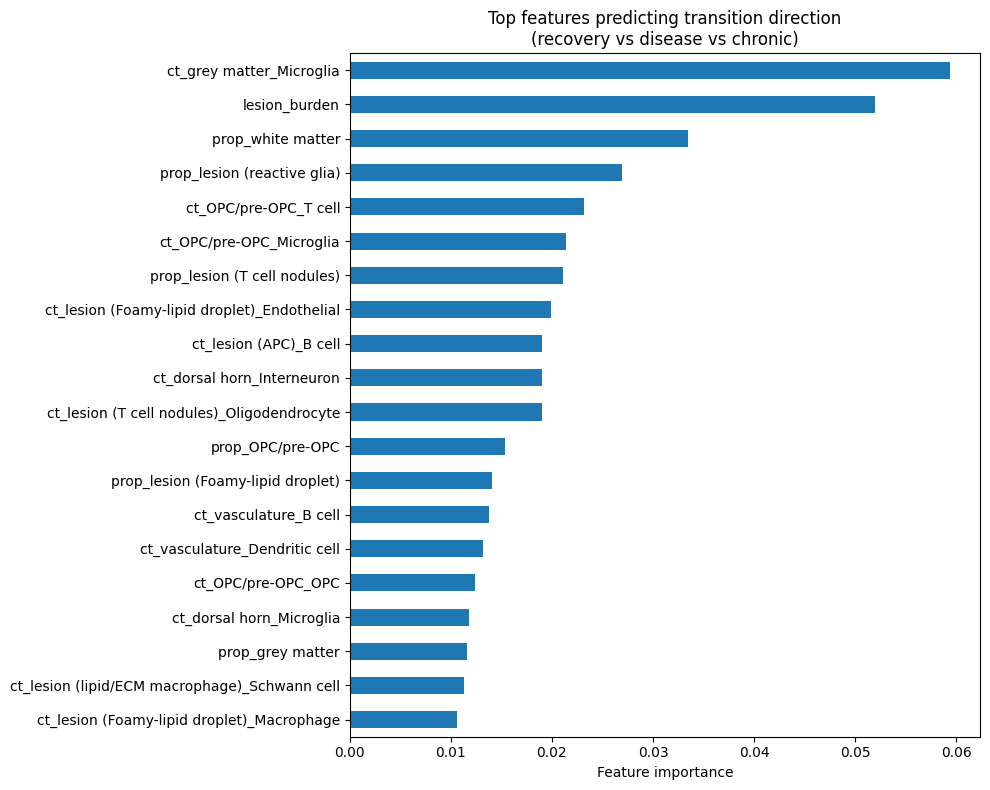


Top compartment proportion features:
  prop_white matter                             0.0335
  prop_lesion (reactive glia)                   0.0269
  prop_lesion (T cell nodules)                  0.0211
  prop_OPC/pre-OPC                              0.0153
  prop_lesion (Foamy-lipid droplet)             0.0141
  prop_grey matter                              0.0116
  prop_lesion (lipid/ECM macrophage)            0.0095
  prop_lesion (activated microglia)             0.0088
  prop_lesion (APC)                             0.0074
  prop_central canal                            0.0058

Top cell-type-in-compartment features:
  ct_grey matter_Microglia                      0.0594
  ct_OPC/pre-OPC_T cell                         0.0232
  ct_OPC/pre-OPC_Microglia                      0.0214
  ct_lesion (Foamy-lipid droplet)_Endothelial   0.0199
  ct_lesion (APC)_B cell                        0.0190
  ct_dorsal horn_Interneuron                    0.0190
  ct_lesion (T cell nodules)_Oligodendrocy

In [ ]:
# Feature importances — what compartment features predict transition direction?
rf.fit(X_cls, y_cls)
importances = pd.Series(rf.feature_importances_, index=feature_cols)

# Top 20 features
top_features = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_features.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("Top features predicting transition direction\n(recovery vs disease vs chronic)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Print grouped by type
print("\nTop compartment proportion features:")
for name, imp in importances[importances.index.str.startswith("prop_")].nlargest(10).items():
    print(f"  {name:45s} {imp:.4f}")

print("\nTop cell-type-in-compartment features:")
for name, imp in importances[importances.index.str.startswith("ct_")].nlargest(10).items():
    print(f"  {name:45s} {imp:.4f}")

## 8. Transition vector similarity (compartment features)

Same analysis as notebook 02, but using interpretable compartment features
instead of Novae embeddings.

In [ ]:
# Transition vectors using compartment features
transitions = {}
for model_name in ["MOG", "PLP"]:
    pairs = get_transition_pairs(model_name)
    for from_s, to_s in pairs:
        k1, k2 = (model_name, from_s), (model_name, to_s)
        if k1 in stage_means and k2 in stage_means:
            vec = stage_means[k2] - stage_means[k1]
            transitions[(model_name, from_s, to_s)] = vec

# Compare transition similarities
comparisons = [
    ("PLP", "PEAK1", "REMISSION1", "PLP", "PEAK2", "REMISSION2",
     "Peak->Remission: cycle 1 vs cycle 2"),
    ("PLP", "REMISSION1", "PEAK2", "PLP", "REMISSION2", "PEAK3",
     "Remission->Peak: relapse 1 vs relapse 2"),
    ("PLP", "PEAK1", "REMISSION1", "PLP", "REMISSION1", "PEAK2",
     "Peak->Remission vs Remission->Peak (should be opposite)"),
    ("PLP", "PLP CFA", "ONSET1", "PLP", "REMISSION1", "PEAK2",
     "First onset vs first relapse"),
]

print("Transition vector similarity (compartment features):")
print("  1.0 = identical direction, -1.0 = opposite\n")

for m1, f1, t1, m2, f2, t2, label in comparisons:
    k1, k2 = (m1, f1, t1), (m2, f2, t2)
    if k1 in transitions and k2 in transitions:
        v1, v2 = transitions[k1], transitions[k2]
        sim = 1 - cosine(v1, v2)
        print(f"  {f1}->{t1} vs {f2}->{t2}")
        print(f"    similarity = {sim:+.4f}  ({label})")
        print()

Transition vector similarity (compartment features):
  1.0 = identical direction, -1.0 = opposite

  PEAK1->REMISSION1 vs PEAK2->REMISSION2
    similarity = +0.0578  (Peak->Remission: cycle 1 vs cycle 2)

  REMISSION1->PEAK2 vs REMISSION2->PEAK3
    similarity = -0.0277  (Remission->Peak: relapse 1 vs relapse 2)

  PEAK1->REMISSION1 vs REMISSION1->PEAK2
    similarity = +0.2033  (Peak->Remission vs Remission->Peak (should be opposite))

  PLP CFA->ONSET1 vs REMISSION1->PEAK2
    similarity = -0.0093  (First onset vs first relapse)



## 9. What specifically changes during remission?

Decompose the PEAK1 -> REMISSION1 transition: which compartments shrink,
which grow, and what cell types change within them?

In [ ]:
# Detailed decomposition of PEAK1 -> REMISSION1
k1, k2 = ("PLP", "PEAK1"), ("PLP", "REMISSION1")
if k1 in stage_means and k2 in stage_means:
    delta = stage_means[k2] - stage_means[k1]
    
    print("=== PEAK1 -> REMISSION1: What changes? ===\n")
    
    # Compartment proportion changes
    print("COMPARTMENT PROPORTION CHANGES:")
    print("  (positive = compartment grows during remission)\n")
    prop_changes = []
    for i, col in enumerate(feature_cols):
        if col.startswith("prop_"):
            name = col.replace("prop_", "")
            prop_changes.append((name, delta[i]))
    prop_changes.sort(key=lambda x: abs(x[1]), reverse=True)
    for name, d in prop_changes:
        if abs(d) > 0.001:
            bar = "+" * int(abs(d) * 200) if d > 0 else "-" * int(abs(d) * 200)
            print(f"  {name:40s} {d:+.4f} {bar}")
    
    # For top changing compartments, show cell type changes within them
    print("\n\nCELL TYPE CHANGES WITHIN KEY COMPARTMENTS:")
    top_comps = [name for name, d in prop_changes[:4]]
    
    for comp in top_comps:
        ct_changes = []
        for i, col in enumerate(feature_cols):
            if col.startswith(f"ct_{comp}_"):
                ct = col.replace(f"ct_{comp}_", "")
                ct_changes.append((ct, delta[i]))
        
        ct_changes.sort(key=lambda x: abs(x[1]), reverse=True)
        significant = [(ct, d) for ct, d in ct_changes if abs(d) > 0.01]
        
        if significant:
            print(f"\n  Within '{comp}':")
            for ct, d in significant[:5]:
                print(f"    {ct:30s} {d:+.4f}")

=== PEAK1 -> REMISSION1: What changes? ===

COMPARTMENT PROPORTION CHANGES:
  (positive = compartment grows during remission)

  lesion (APC)                             -0.1464 -----------------------------
  grey matter                              +0.0524 ++++++++++
  white matter                             +0.0326 ++++++
  lesion (T cell nodules)                  -0.0293 -----
  dorsal horn                              +0.0278 +++++
  lesion (reactive glia)                   +0.0274 +++++
  dorsal root ganglion                     +0.0168 +++
  vasculature                              +0.0114 ++
  OPC/pre-OPC                              +0.0081 +
  lesion (lipid/ECM macrophage)            -0.0060 -
  lesion (activated microglia)             +0.0044 
  central canal                            +0.0022 
  lesion (Foamy-lipid droplet)             -0.0017 


CELL TYPE CHANGES WITHIN KEY COMPARTMENTS:

  Within 'lesion (APC)':
    Dendritic cell                 +0.5345
    Macrophage  